In [136]:

import hbsir
import matplotlib
import numpy as np
import pandas as pd
import sns
import seaborn as sns

import statsmodels.formula.api as smf


In [126]:
import yaml

def extract_table_names(yaml_file_path):
    with open(yaml_file_path, 'r', encoding='utf-8') as file:
        schema = yaml.safe_load(file)

    table_names = set()

    # Extract top-level tables (direct keys)
    for key in schema.keys():
        if isinstance(schema[key], dict) and 'instructions' in schema[key]:
            table_names.add(key)

    # Extract tables from table_list sections
    for section in schema.values():
        if isinstance(section, dict) and 'table_list' in section:
            table_list = section['table_list']
            if isinstance(table_list, dict):
                for tables in table_list.values():
                    if isinstance(tables, list):
                        table_names.update(tables)
                    elif isinstance(tables, str):
                        table_names.add(tables)
            elif isinstance(table_list, list):
                table_names.update(table_list)

    # Remove None if present and sort alphabetically
    table_names.discard(None)
    return sorted(table_names)

# Usage example
yaml_file = r'.\schema.yaml'
tables = extract_table_names(yaml_file)
print(tables)

['Administrative_Divisions', 'Cash_Incomes', 'Equivalence_Scale', 'Expenditures', 'Imputed_Rent', 'Income_Breakdown', 'Members_Income_Breakdown', 'Members_Total_Income', 'NonCash_Incomes', 'NonCash_Incomes_Excluding_Imputed_Rent', 'Number_of_Members', 'Original_Expenditures', 'Original_Outlays', 'Outlays', 'Season', 'Total_Expenditure', 'Total_Income', 'Total_Outlay', 'Weight', '_long_other_income', 'census_month', 'cloth', 'communication', 'durable', 'education', 'employment_income', 'entertainment', 'external.hbsir_weights', 'food', 'furniture', 'home', 'hotel', 'house_specifications', 'household_information', 'investment', 'medical', 'members_properties', 'miscellaneous', 'old_rural_house_specifications', 'old_urban_house_specifications', 'other_income', 'private_employment_income', 'public_employment_income', 'self_employed_income', 'subsidy', 'tobacco', 'transportation']


In [128]:
# import os
# lyear = 1391
# hbsir.setup(years=f"{lyear}",method="download_cleaned",download_source="mirror")
# years = [lyear]
# tables = extract_table_names(yaml_file)
#
# for year in years:
#     for t in tables:
#         try:
#             print("Loading year", year)
#             table = hbsir.load_table(t, years=year)
#             directory_path = rf'D:\regres project\csvs data\{t}\{year}'
#             os.makedirs(directory_path, exist_ok=True)
#             output = os.path.join(directory_path, f'{t}_{year}.csv')
#             table.to_csv(output, index=False)
#             print("Table", year, "done!")
#         except Exception as e:
#             print(f"Error processing year {year}: {e}")
#             continue

Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Table 1391 done!
Loading year 1391
Error processing year 1391: 
Loading 

In [59]:
def csvfind(tableName , year ):
    path = "D:\\regres project\\csvs data\\" + tableName +"\\"+str(year)+"\\"+tableName+"_"+str(year)+".csv"
    return  pd.read_csv(path)

In [60]:
def get_total_income(year):
    a = csvfind("Total_Income", year)
    return a.groupby("ID")["Income"].sum().reset_index()

In [61]:
expenditures_95 = csvfind(tableName="Expenditures", year=1395)

In [62]:

expenditures_95 = hbsir.add_attribute(table=expenditures_95, name='Province',year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="Urban_Rural",year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="County",year_col="Year" ,id_col="ID")


In [63]:
members_properties_95 = csvfind(tableName="members_properties", year=1395)
employment_income_95 = csvfind("employment_income",1395)

In [64]:
head_edu = members_properties_95[members_properties_95["Member_Number"] == 1][["ID", "Education_Level"]]
# hh_income = employment_income_95.groupby("ID")["Annual_Continuous_Income"].sum().reset_index()
hh_income = get_total_income(year=1395)
hh_income.rename(columns={"Income": "Household_Income"}, inplace=True)

In [65]:
merged = pd.merge(hh_income, head_edu, on="ID")
merged = merged.where(pd.notnull(merged), "None")
print(merged.head())


            ID  Household_Income Education_Level
0  10001000120        66920000.0            None
1  10001000123        96840000.0            None
2  10001000126       143460000.0            None
3  10001000129        38960000.0            None
4  10001000132       224920000.0            None


In [66]:
mean_income_by_edu = merged.groupby("Education_Level")["Household_Income"].mean().sort_values(ascending=False)
print(mean_income_by_edu)


Education_Level
Doctoral                9.434833e+08
Masters                 4.812501e+08
Bachelors               3.972277e+08
Short_Cycle_Tertiary    3.445846e+08
Pre_University          2.820993e+08
Lower_Secondary         2.216930e+08
Higher_Secondary        2.204085e+08
Primary                 2.110458e+08
Unofficial              1.897082e+08
None                    1.473819e+08
Name: Household_Income, dtype: float64


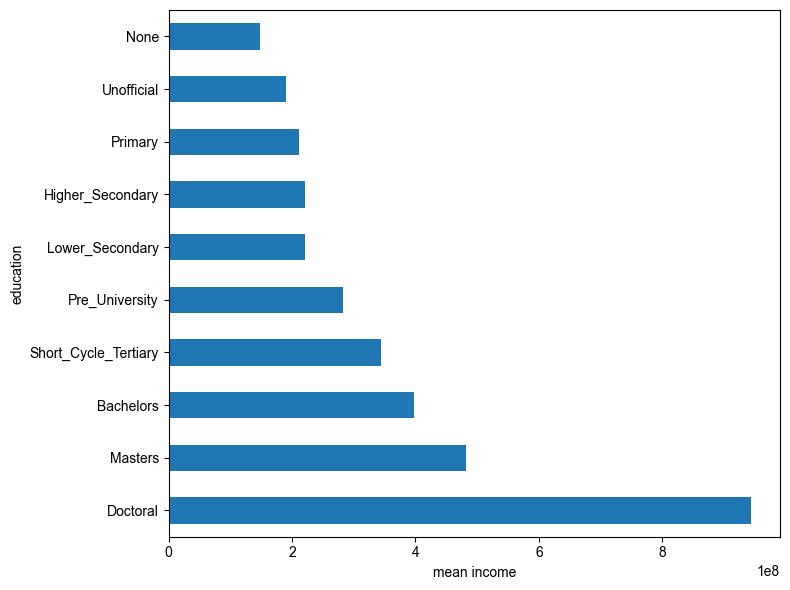

In [67]:
import matplotlib.pyplot as plt

mean_income_by_edu.plot(kind="barh", figsize=(8, 6))
plt.xlabel("mean income")
plt.ylabel("education")
plt.tight_layout()
plt.show()

In [68]:
from sklearn.linear_model import LinearRegression


def regression_with_interactions_sklearn(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساخت متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}:{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی به X
    X = pd.concat([X] + interaction_terms, axis=1)

    # اضافه کردن یک ستون ثابت (intercept) برای مدل
    X['constant'] = 1

    # ساخت مدل رگرسیونی
    model = LinearRegression()

    # برازش مدل
    model.fit(X, y)

    # نمایش ضرایب
    coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
    return coef_df

# فرض کنید df دیتافریم شماست که شامل متغیرهای X1, X2, X3 و y است
# independent_vars = ['X1', 'X2', 'X3']
# # لیست ستون‌ها برای متغیرهای ورودی
# target_var = 'y'  # اسم ستون هدف
# df = pd.DataFrame()
# result = regression_with_interactions_sklearn(df, independent_vars, target_var)
# print(result)

In [69]:
import statsmodels.api as sm
from itertools import combinations

def regression_with_interactions(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساختن متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}_&_{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی
    X = pd.concat([X] + interaction_terms, axis=1)

    # افزودن ستون ثابت
    X = sm.add_constant(X)

    # برازش مدل
    model = sm.OLS(y, X).fit()

    return model

In [70]:
merged = pd.merge(expenditures_95, members_properties_95, on="ID")


In [71]:
table_1395 = expenditures_95
# table_1395 = hbsir.add_attribute(table=table_1395, name='Province',year_col="Year" ,id_col="ID")
# table_1395 = hbsir.add_attribute(table=table_1395, name="Urban_Rural",year_col="Year" ,id_col="ID")
# table_1395 = hbsir.add_attribute(table=table_1395, name="County",year_col="Year" ,id_col="ID")
hhinc_1395 = csvfind(tableName="employment_income", year=1395)
members_1395 = csvfind("members_properties",1395)

C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_7708\3727247502.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)


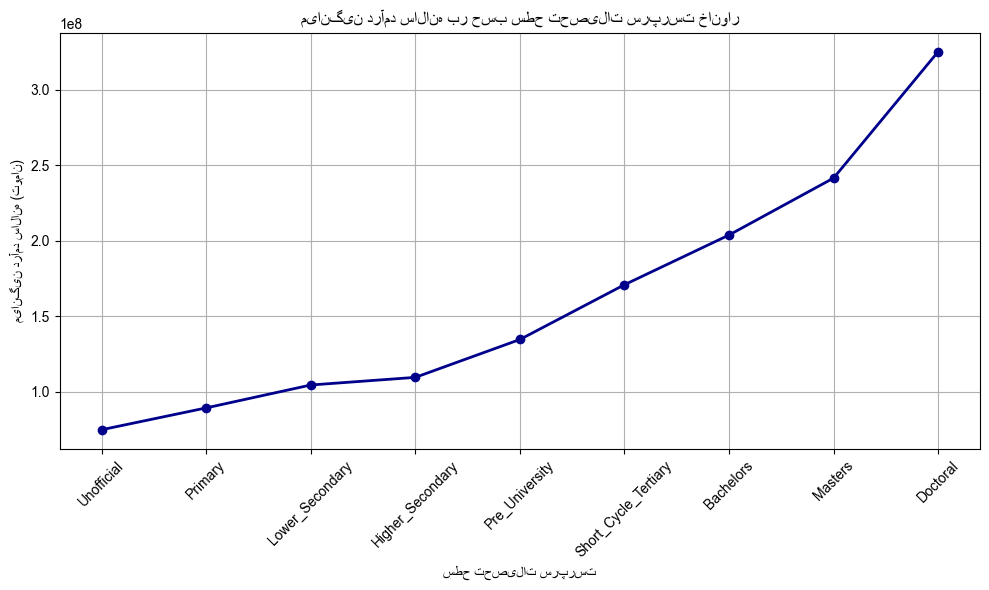

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# لیست مرتب‌شده سطح تحصیلات
valid_levels = [
    "Unofficial",
    "Primary",
    "Lower_Secondary",
    "Higher_Secondary",
    "Pre_University",
    "Short_Cycle_Tertiary",
    "Bachelors",
    "Masters",
    "Doctoral"
]

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df_1395 = members_1395[
    (members_1395["Member_Number"] == 1) & (members_1395["Education_Level"].isin(valid_levels))].copy()

# تبدیل به نوع مرتب Categorical
df_1395["Education_Level"] = pd.Categorical(df_1395["Education_Level"], categories=valid_levels, ordered=True)

# اضافه کردن درآمد سرپرست‌ها از hhinc
df_1395 = df_1395.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID",
    how="left"
)

# حذف ردیف‌هایی که درآمد ندارن
df_1395 = df_1395.dropna(subset=["Annual_Continuous_Income"])

# محاسبه میانگین درآمد برای هر سطح تحصیل
mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)

# 📈 رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(mean_income_1395.index, mean_income_1395.values, marker='o', color='darkblue', linewidth=2)
plt.xlabel("سطح تحصیلات سرپرست")
plt.ylabel("میانگین درآمد سالانه (تومان)")
plt.title("میانگین درآمد سالانه بر حسب سطح تحصیلات سرپرست خانوار")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [73]:
def uploadingData(year):
    table = csvfind("Expenditures", year=year)
    table = hbsir.add_attribute(table=table, name='Province', year_col="Year", id_col="ID")
    table = hbsir.add_attribute(table=table, name="Urban_Rural", year_col="Year", id_col="ID")
    table = hbsir.add_attribute(table=table, name="County", year_col="Year", id_col="ID")
    hhinc = csvfind("employment_income", year=year)
    members = csvfind("members_properties", year=year)
    return table, hhinc, members
def proccessData(members,hhinc):
    # ---------- پردازش ----------
    df = members[(members["Member_Number"] == 1) &
                 (members["Education_Level"].isin(valid_levels))].copy()
    df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

    df = df.merge(
        hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
        on="ID", how="left"
    )
    return df
edu_map = {
    "Unofficial": 0,
    "Primary": 5,
    "Lower_Secondary": 8,
    "Higher_Secondary": 12,
    "Pre_University": 13,
    "Short_Cycle_Tertiary": 14,
    "Bachelors": 16,
    "Masters": 18,
    "Doctoral": 22
}

In [74]:
# tables=[]
# for year in range(1395, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [75]:
# import hbsir
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import statsmodels.formula.api as smf
#
# valid_levels = [
#     "Unofficial", "Primary", "Lower_Secondary", "Higher_Secondary",
#     "Pre_University", "Short_Cycle_Tertiary", "Bachelors", "Masters", "Doctoral"
# ]
#
# edu_map = {
#     "Unofficial": 0, "Primary": 5, "Lower_Secondary": 8, "Higher_Secondary": 12,
#     "Pre_University": 13, "Short_Cycle_Tertiary": 14, "Bachelors": 16,
#     "Masters": 18, "Doctoral": 22
# }
#
# for year in range(1396, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # --- بارگذاری داده‌ها ---
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#
#         # Add urban/rural
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         # Remove rows without income
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#
#         # Convert Urban_Rural to 0 and 1
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # --- Modeling ---
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#         #
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # --- Prediction data ---
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         # --- Plotting ---
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#
#         # Without interaction + actual points
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             # Regression line
#             subset_line = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset_line["Years_Edu"], subset_line["pred_no_inter"], color=color, label=label)
#
#             # Actual points
#             subset_points = df[df["Urban"] == u]
#             axes[0].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
#                             color=color, alpha=0.5, s=20)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         # With interaction + actual points
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset_line = plot_df[plot_df["Urban"] == u]
#             axes[1].plot(subset_line["Years_Edu"], subset_line["pred_inter"], color=color, label=label)
#
#             subset_points = df[df["Urban"] == u]
#             axes[1].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
#                             color=color, alpha=0.5, s=20)
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [76]:
# for year in range(1395, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#
#         # Gender column: Assuming Gender column exists in members
#         # Male -> 1, Female -> 0
#         df["Gender_Binary"] = df["Sex"].apply(lambda x: 1 if str(x).lower() == "male" else 0)
#
#         # Remove rows without income or gender
#         df = df.dropna(subset=["Annual_Continuous_Income", "Gender_Binary"])
#
#         # ---------- Model ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Gender_Binary", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Gender_Binary", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#         #
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- Plot ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Gender_Binary": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for g, color, label in [(0, "purple", "Female"), (1, "green", "Male")]:
#             subset = plot_df[plot_df["Gender_Binary"] == g]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [77]:
# ## spouse income
# for year in range(1395, 1402):
#
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = members[(members["Relationship"] == "Spouse") &
#                      (members["Education_Level"].isin(valid_levels))].copy()
#         df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)
#         df = df.merge(
#             hhinc[["ID", "Annual_Continuous_Income"]],
#             on="ID", how="left"
#         )
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [78]:
# ## family income
# for year in range(1395, 1402):
#
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = pd.merge(members, hhinc, on=["ID","Member_Number"], how="left")
#
#
#
#
#         df = members[(members["Education_Level"].isin(valid_levels))].copy()
#         df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)
#
#         df = df.merge(
#             hhinc[["ID","Member_Number", "Annual_Continuous_Income"]],
#            on=["ID","Member_Number"], how="left"
#         )
#         df = df.dropna(subset=["Annual_Continuous_Income" , "Education_Level"])
#
#         result = df.groupby('ID').agg({
#         'Annual_Continuous_Income': 'sum' ,"Years_Edu":"max"}).reset_index()
#
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         result = result.merge(urban_rural, on="ID", how="left")
#         df = result
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [79]:
# #for year in range(1395, 1402):
# year = 1402
# print(f"---------------{year}---------------")
# food = csvfind("food", year)
# Tobacco = csvfind("tobacco", year)
# Cloth = csvfind("cloth", year)
# Home = csvfind("home", year)
# Furniture = csvfind("furniture", year)
# Medical = csvfind("medical", year)
# Transportation = csvfind("transportation", year)
# Communication = csvfind("communication", year)
# Entertainment = csvfind("entertainment", year)
# # Education = csvfind("education",year)
# Hotel = csvfind("hotel", year)
# Miscellaneous = csvfind("miscellaneous", year)
# Durable = csvfind("durable", year)
# Investment = csvfind("investment", year)
# employment_income = csvfind("employment_income", year)
# tables = [food, Tobacco, Cloth, Home, Furniture, Medical, Transportation, Communication, Entertainment, Hotel,
#           Miscellaneous, Durable, Investment]
# employment_income = get_total_income(year)
# # for table in tables:
# for table in tables:
#     try:
#         result = employment_income
#         result.rename(columns={'Income': 'Monthly_Income'}, inplace=True)
#         result['Monthly_Income'] = result['Monthly_Income']
#         name = table['Table_Name'].loc[0]
#         table['Expenditure'] = table['Expenditure'].fillna(0)
#         table = table.groupby('ID').agg({'Expenditure': 'sum'}).reset_index()
#         result = pd.merge(result, table, on="ID")
#         result_main = result
#         result_main = result_main[result_main['Expenditure'] < result_main['Monthly_Income']]
#         result['Expenditure'] = result['Expenditure'] / result['Monthly_Income']
#         result['Expenditure'] = result['Expenditure'] * 100
#         result = result[result['Expenditure'] < 100]
#
#     except Exception as e:
#         print(f"<UNK> Error processing table {name}: {e}")
#     print(f"---------------{name}-----------------")
#     # for table in tables:
#     result = result.groupby('Monthly_Income').agg({
#         'Expenditure': 'mean'}).reset_index()
#     plt.figure(figsize=(5, 3))
#     plt.plot(result['Monthly_Income'], result['Expenditure'], color='darkblue', linewidth=2)
#     plt.xlabel("income")
#     plt.ylabel(f"{name} Expenditure percent in Income")
#     plt.title("percent")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
#
#     result_main = result_main.groupby('Monthly_Income').agg({
#         'Expenditure': 'mean'}).reset_index()
#     plt.figure(figsize=(5, 3))
#     plt.plot(result_main['Monthly_Income'], result_main['Expenditure'], color='darkblue', linewidth=2)
#     plt.xlabel("income")
#     plt.ylabel(f"{name} Expenditure")
#     plt.title("all")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

---------------1393---------------
---------------investment-----------------


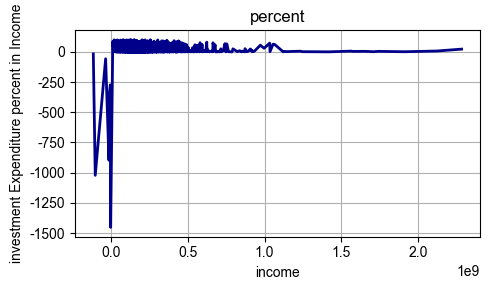

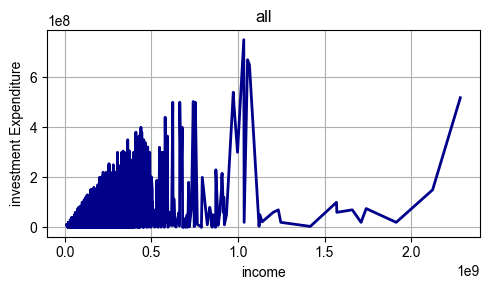

---------------1394---------------
---------------investment-----------------


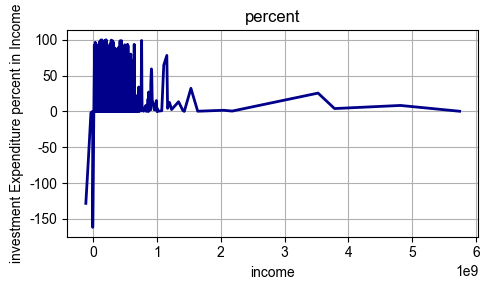

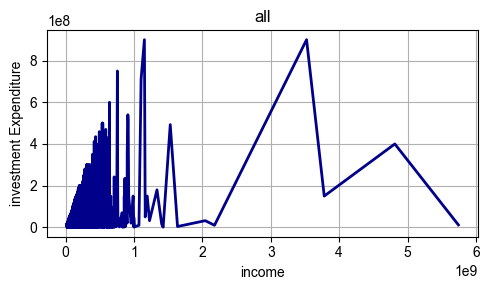

---------------1395---------------
---------------investment-----------------


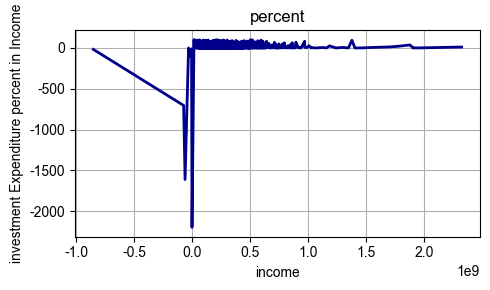

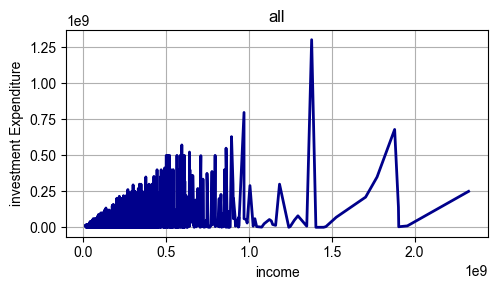

---------------1396---------------
---------------investment-----------------


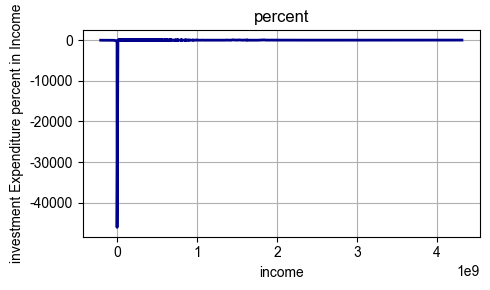

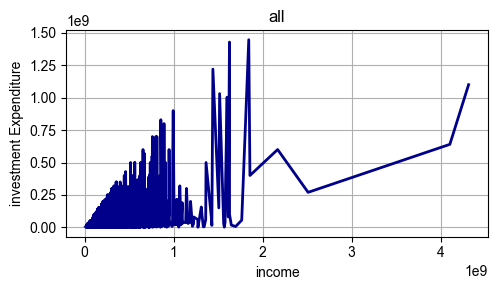

---------------1397---------------
---------------investment-----------------


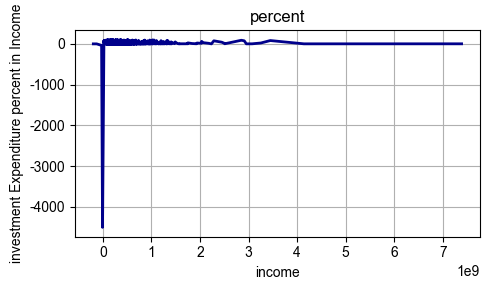

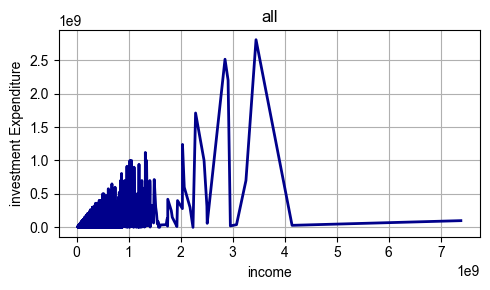

---------------1398---------------
---------------investment-----------------


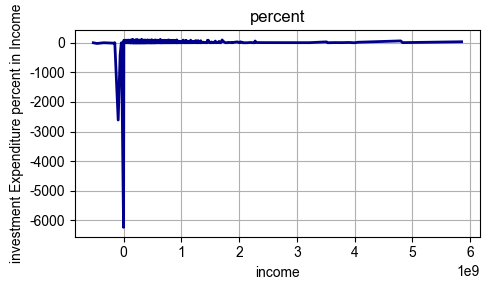

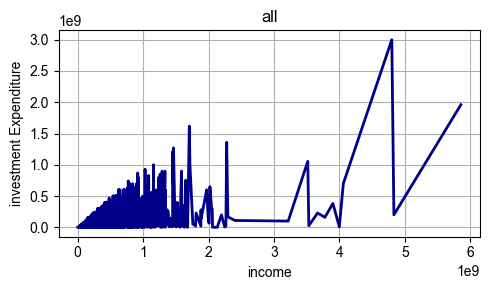

---------------1399---------------
---------------investment-----------------


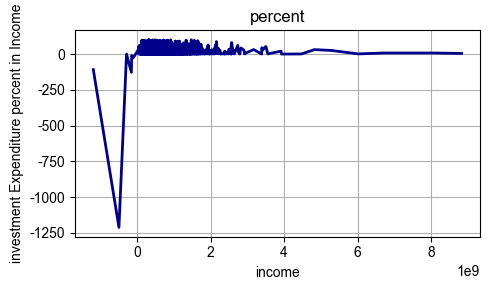

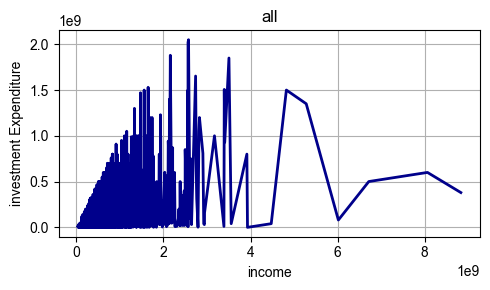

---------------1400---------------
---------------investment-----------------


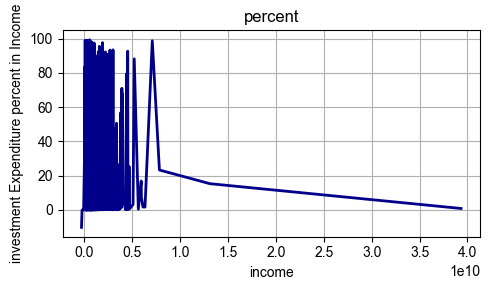

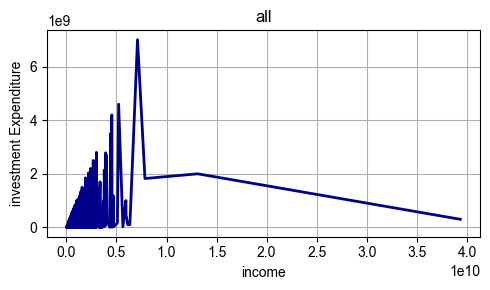

---------------1401---------------
---------------investment-----------------


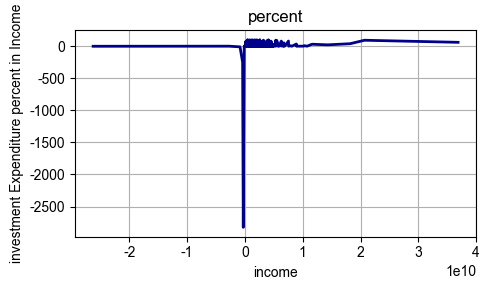

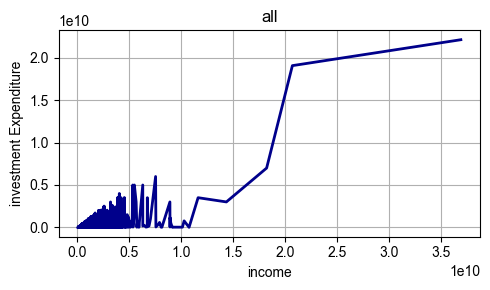

---------------1402---------------
---------------investment-----------------


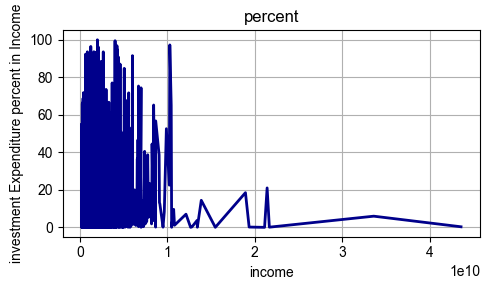

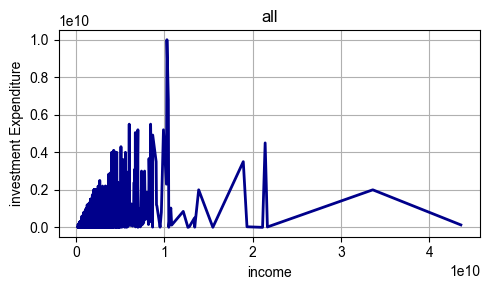

In [80]:
for year in range(1393, 1403):
    # year = 1394
    print(f"---------------{year}---------------")
    # food = csvfind("food", year)
    # Tobacco = csvfind("tobacco", year)
    # Cloth = csvfind("cloth", year)
    # Home = csvfind("home", year)
    # Furniture = csvfind("furniture", year)
    # Medical = csvfind("medical", year)
    # Transportation = csvfind("transportation", year)
    # Communication = csvfind("communication", year)
    # Entertainment = csvfind("entertainment", year)
    # # Education = csvfind("education",year)
    # Hotel = csvfind("hotel", year)
    # Miscellaneous = csvfind("miscellaneous", year)
    # Durable = csvfind("durable", year)
    Investment = csvfind("investment", year)
    employment_income = csvfind("employment_income", year)
    tables = [
        # food, Tobacco, Cloth, Home, Furniture, Medical, Transportation, Communication, Entertainment, Hotel,
        #       Miscellaneous, Durable,
        Investment]
    employment_income = get_total_income(year)
    # for table in tables:
    for table in tables:
        try:
            result = employment_income
            result.rename(columns={'Income': 'Monthly_Income'}, inplace=True)
            result['Monthly_Income'] = result['Monthly_Income']
            name = table['Table_Name'].loc[0]
            table['Expenditure'] = table['Expenditure'].fillna(0)
            table = table.groupby('ID').agg({'Expenditure': 'sum'}).reset_index()
            result = pd.merge(result, table, on="ID")
            result_main = result
            result_main = result_main[result_main['Expenditure'] < result_main['Monthly_Income']]
            result['Expenditure'] = result['Expenditure'] / result['Monthly_Income']
            result['Expenditure'] = result['Expenditure'] * 100
            result = result[result['Expenditure'] < 100]

        except Exception as e:
            print(f"<UNK> Error processing table {name}: {e}")
        print(f"---------------{name}-----------------")
        # for table in tables:
        result = result.groupby('Monthly_Income').agg({
            'Expenditure': 'mean'}).reset_index()
        plt.figure(figsize=(5, 3))
        plt.plot(result['Monthly_Income'], result['Expenditure'], color='darkblue', linewidth=2)
        plt.xlabel("income")
        plt.ylabel(f"{name} Expenditure percent in Income")
        plt.title("percent")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        result_main = result_main.groupby('Monthly_Income').agg({
            'Expenditure': 'mean'}).reset_index()
        plt.figure(figsize=(5, 3))
        plt.plot(result_main['Monthly_Income'], result_main['Expenditure'], color='darkblue', linewidth=2)
        plt.xlabel("income")
        plt.ylabel(f"{name} Expenditure")
        plt.title("all")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

eshteghal zanan va daramad

In [81]:
plt.rcParams['font.family'] ='Arial'
plt.rcParams['axes.unicode_minus'] = False

In [82]:
Members_Total_Income1400 = csvfind("Members_Total_Income", 1400)
members1400 = csvfind("members_properties", 1400)
members1400 = members1400[members1400['Sex'] == 'Male']
mergeMen = pd.merge(members1400, Members_Total_Income1400, on=['ID','Member_Number'])
mergeMen["Year"] =1400
mergeMen = hbsir.add_attribute(table=mergeMen, name='Province',year_col="Year" ,id_col="ID")
mergeMen = hbsir.add_attribute(table=mergeMen, name="Urban_Rural",year_col="Year" ,id_col="ID")
mergeMen = hbsir.add_attribute(table=mergeMen, name="County",year_col="Year" ,id_col="ID")


In [83]:
Members_Total_Income1400 = csvfind("Members_Total_Income", 1400)
members1400 = csvfind("members_properties", 1400)
members1400 = members1400[members1400['Sex'] == 'Female']
mergeWoman = pd.merge(members1400, Members_Total_Income1400, on=['ID','Member_Number'])
mergeWoman["Year"] =1400
mergeWoman = hbsir.add_attribute(table=mergeWoman, name='Province',year_col="Year" ,id_col="ID")
mergeWoman = hbsir.add_attribute(table=mergeWoman, name="Urban_Rural",year_col="Year" ,id_col="ID")
mergeWoman = hbsir.add_attribute(table=mergeWoman, name="County",year_col="Year" ,id_col="ID")


In [84]:
print(mergeWoman.head())

   Year_x           ID  Member_Number Relationship     Sex  Age Is_Literate  \
0    1400  20001384220              2       Spouse  Female   30        True   
1    1400  20013397029              2       Spouse  Female   47        True   
2    1400  20001384225              2       Spouse  Female   43        True   
3    1400  20001384232              2       Spouse  Female   35        True   
4    1400  20001384235              2       Spouse  Female   70       False   

  Is_Student  Education_Level Marital_Status Activity_Status  Year_y  \
0      False   Pre_University        Married     Housekeeper    1400   
1      False          Primary        Married     Housekeeper    1400   
2      False   Pre_University        Married     Housekeeper    1400   
3      False  Lower_Secondary        Married     Housekeeper    1400   
4        NaN              NaN        Married     Housekeeper    1400   

       Income  Year Province Urban_Rural   County  
0  10920000.0  1400  Markazi       Rural

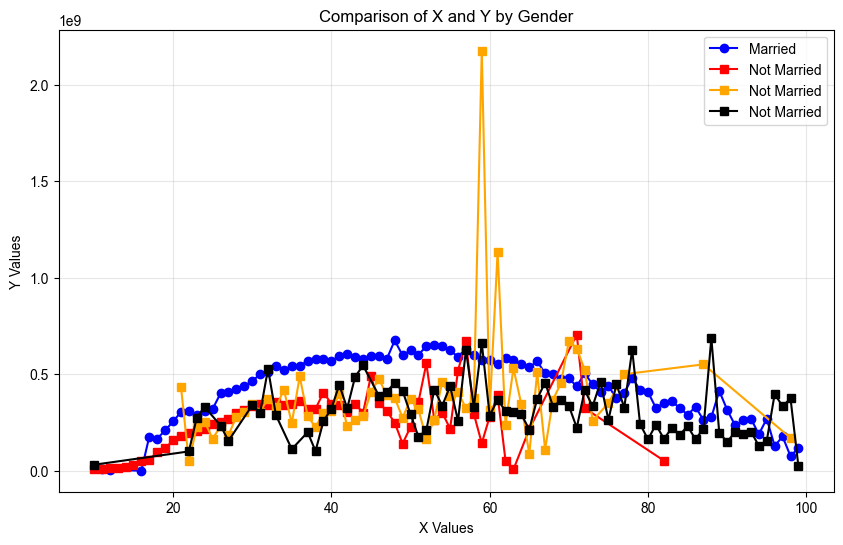

In [86]:
Married_man =mergeMen[mergeMen["Marital_Status"] == "Married"].groupby("Age")["Income"].mean().reset_index()
Bachelor_man = mergeMen[mergeMen["Marital_Status"] == "Bachelor"].groupby("Age")["Income"].mean().reset_index()
Divorced_man = mergeMen[mergeMen["Marital_Status"] == "Divorced"].groupby("Age")["Income"].mean().reset_index()
Widowed_man = mergeMen[mergeMen["Marital_Status"] == "Widowed"].groupby("Age")["Income"].mean().reset_index()


plt.figure(figsize=(10, 6))

plt.plot(Married_man["Age"], Married_man['Income'],
         label='Married', color='blue', marker='o', linestyle='-')

plt.plot(Bachelor_man['Age'], Bachelor_man['Income'],
         label='Not Married', color='red', marker='s', linestyle='-')

plt.plot(Divorced_man['Age'], Divorced_man['Income'],
         label='Not Married', color='orange', marker='s', linestyle='-')

plt.plot(Widowed_man['Age'], Widowed_man['Income'],
         label='Not Married', color='black', marker='s', linestyle='-')

plt.title('Comparison of Men by Marrige')
plt.xlabel('Age Men')
plt.ylabel('Income ')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

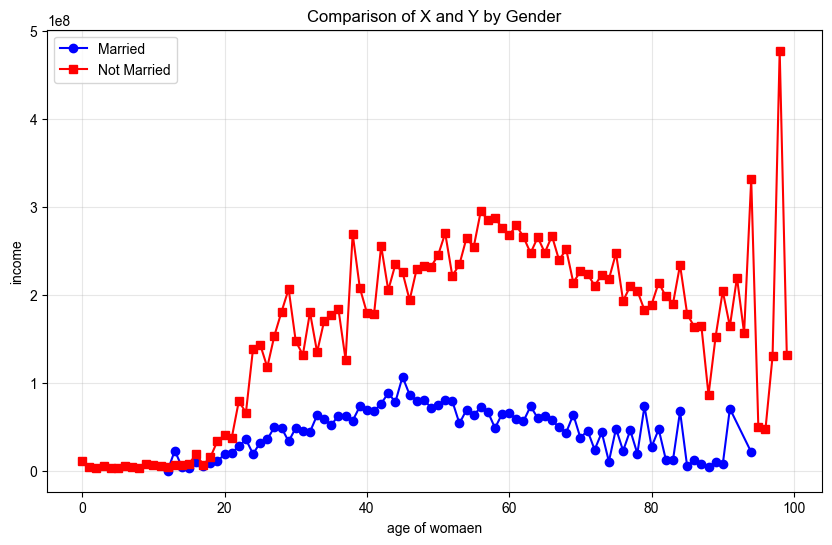

In [90]:
Rural_woman =mergeWoman[mergeWoman["Marital_Status"] == "Married"]
Urban_woman = mergeWoman[mergeWoman["Marital_Status"] != "Married"]
Rural_woman = Rural_woman.groupby("Age")["Income"].mean().reset_index()
Urban_woman = Urban_woman.groupby("Age")["Income"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(Rural_woman["Age"], Rural_woman['Income'],
         label='Married', color='blue', marker='o', linestyle='-')

plt.plot(Urban_woman['Age'], Urban_woman['Income'],
         label='Not Married', color='red', marker='s', linestyle='-')

plt.title('Comparison of X and Y by Gender')
plt.xlabel('age of womaen')
plt.ylabel('income')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

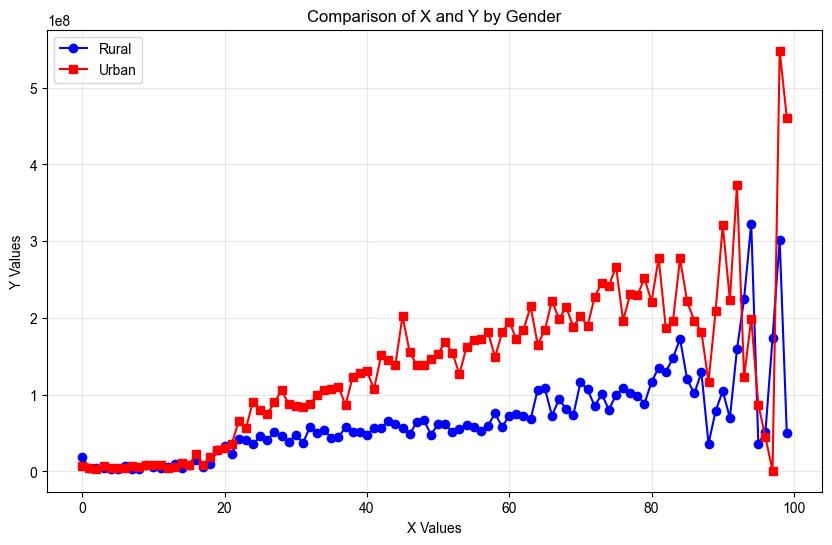

In [91]:
Rural_woman =mergeWoman[mergeWoman["Urban_Rural"] == "Rural"]
Urban_woman = mergeWoman[mergeWoman["Urban_Rural"] == "Urban"]
Rural_woman = Rural_woman.groupby("Age")["Income"].mean().reset_index()
Urban_woman = Urban_woman.groupby("Age")["Income"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(Rural_woman["Age"], Rural_woman['Income'],
         label='Rural', color='blue', marker='o', linestyle='-')

plt.plot(Urban_woman['Age'], Urban_woman['Income'],
         label='Urban', color='red', marker='s', linestyle='-')

plt.title('Comparison of X and Y by Gender')
plt.xlabel('X Values')
plt.ylabel('Y Values')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_7708\1352844035.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]


****************************************** 1393****************************************** 
pay gap: 20.02 %
_____________Female____________
mean_income_of_women : 88722950 Rial
Female Labor Force Participation Rate in 1393 :92.44%
Female_Income_Recipiency_Rate :92.62%
_____________Male____________
mean_income_of_men : 110936931 Rial
Male Labor Force Participation Rate in 1393 :98.74%
Male_Income_Recipiency_Rate :95.22%


C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_7708\1352844035.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]


****************************************** 1394****************************************** 
pay gap: 19.65 %
_____________Female____________
mean_income_of_women : 104110780 Rial
Female Labor Force Participation Rate in 1394 :92.44%
Female_Income_Recipiency_Rate :92.40%
_____________Male____________
mean_income_of_men : 129578672 Rial
Male Labor Force Participation Rate in 1394 :98.74%
Male_Income_Recipiency_Rate :94.24%


C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_7708\1352844035.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]


...

****************************************** 1400****************************************** 
pay gap: 13.58 %
_____________Female____________
mean_income_of_women : 429403379 Rial
Female Labor Force Participation Rate in 1400 :95.20%
Female_Income_Recipiency_Rate :95.12%
_____________Male____________
mean_income_of_men : 496855442 Rial
Male Labor Force Participation Rate in 1400 :98.94%
Male_Income_Recipiency_Rate :95.80%


C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_7708\1352844035.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]


****************************************** 1401****************************************** 
pay gap: 23.25 %
_____________Female____________
mean_income_of_women : 596335227 Rial
Female Labor Force Participation Rate in 1401 :95.36%
Female_Income_Recipiency_Rate :95.71%
_____________Male____________
mean_income_of_men : 776990743 Rial
Male Labor Force Participation Rate in 1401 :98.83%
Male_Income_Recipiency_Rate :96.40%


C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_7708\1352844035.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]


****************************************** 1402****************************************** 
pay gap: 28.71 %
_____________Female____________
mean_income_of_women : 833152854 Rial
Female Labor Force Participation Rate in 1402 :95.45%
Female_Income_Recipiency_Rate :95.41%
_____________Male____________
mean_income_of_men : 1168709471 Rial
Male Labor Force Participation Rate in 1402 :98.95%
Male_Income_Recipiency_Rate :96.68%


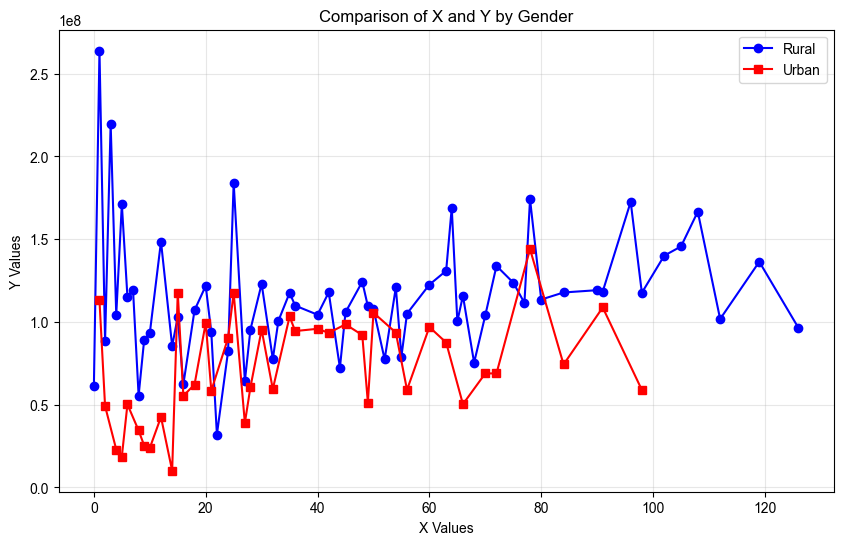

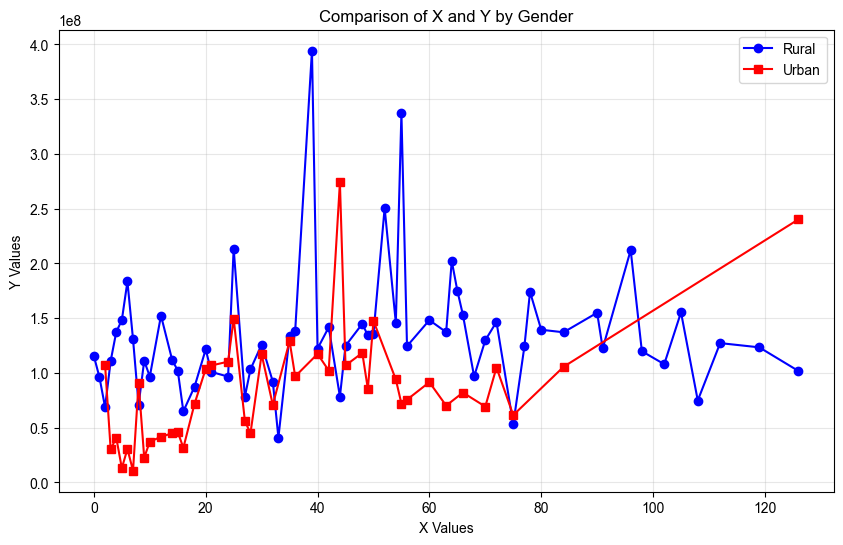

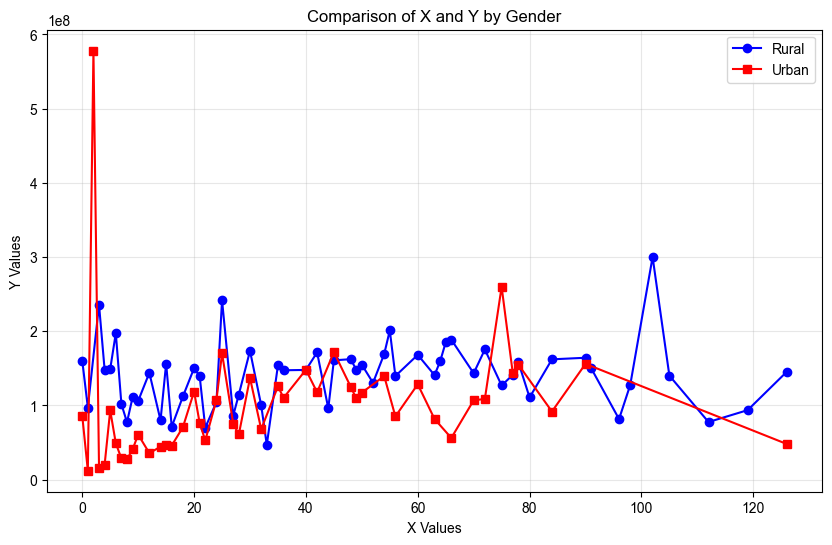

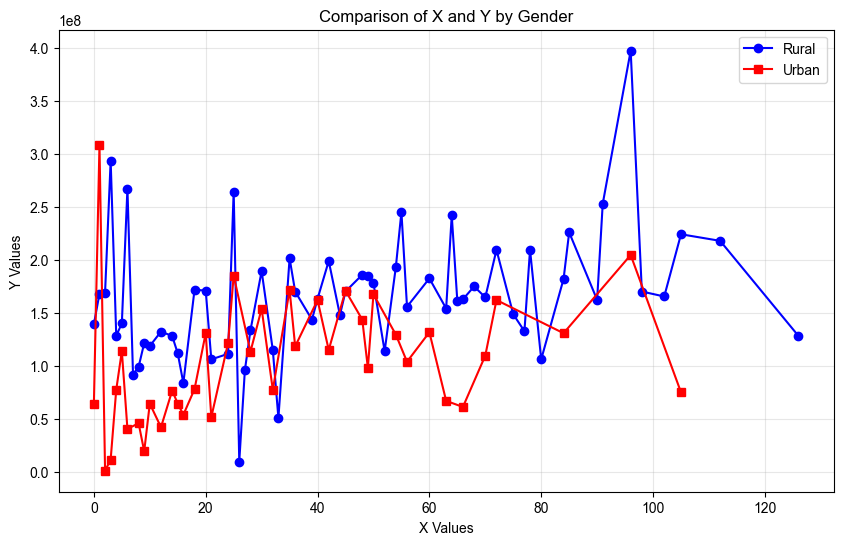

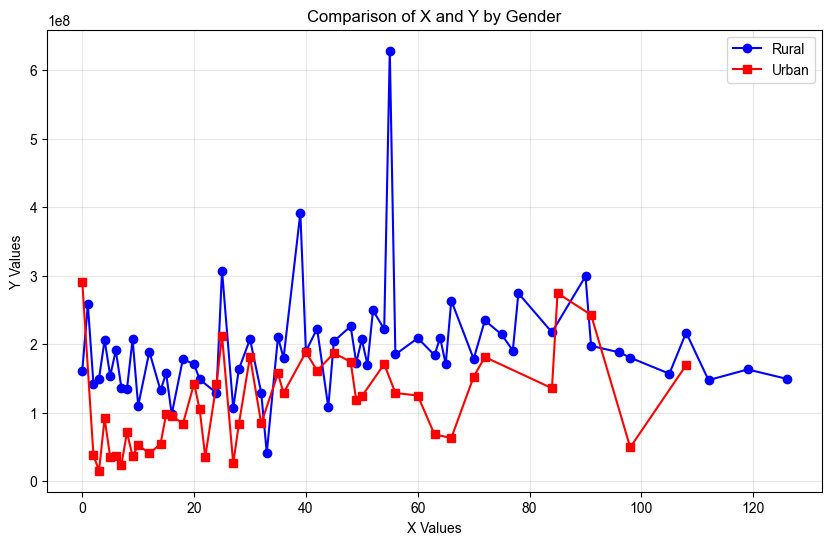

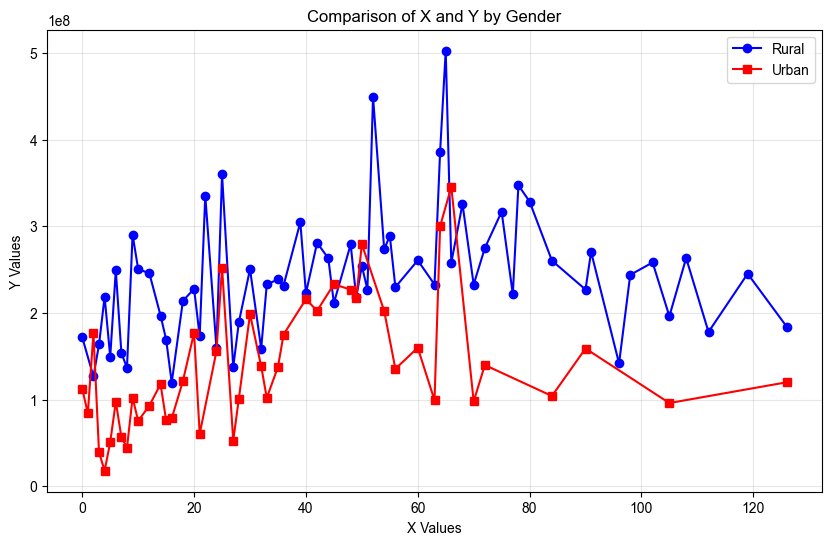

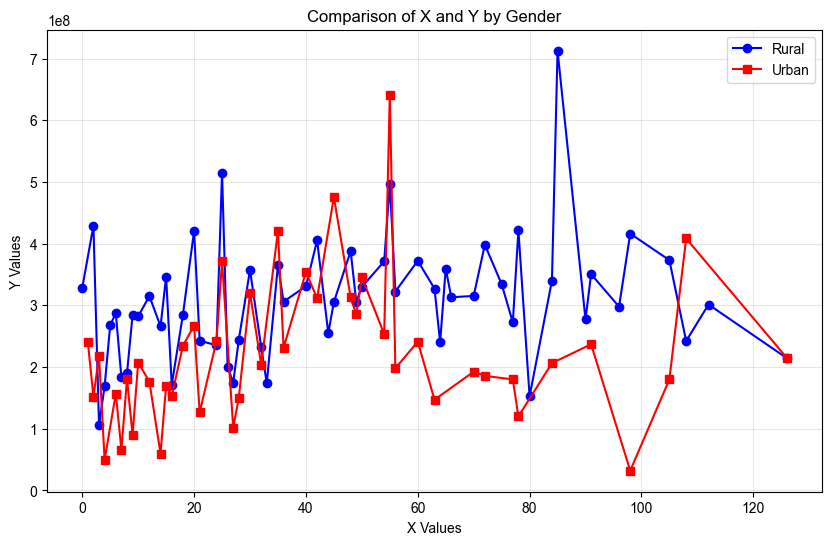

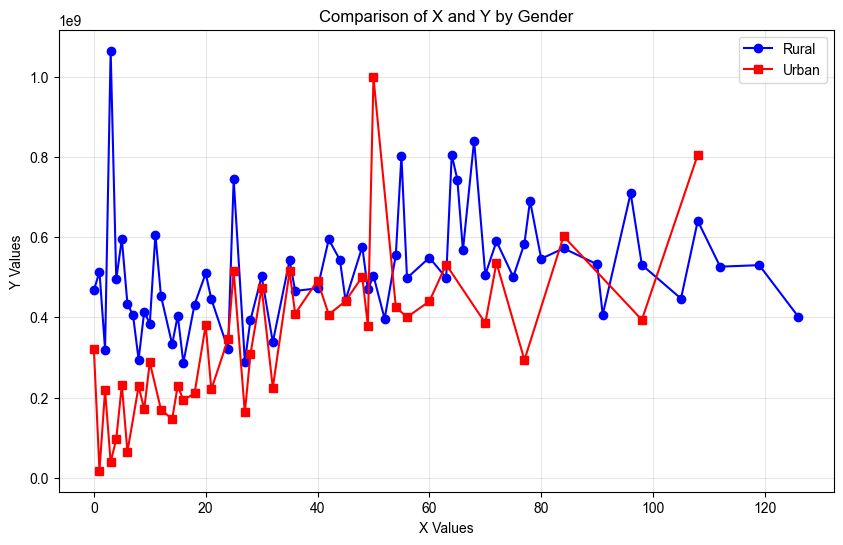

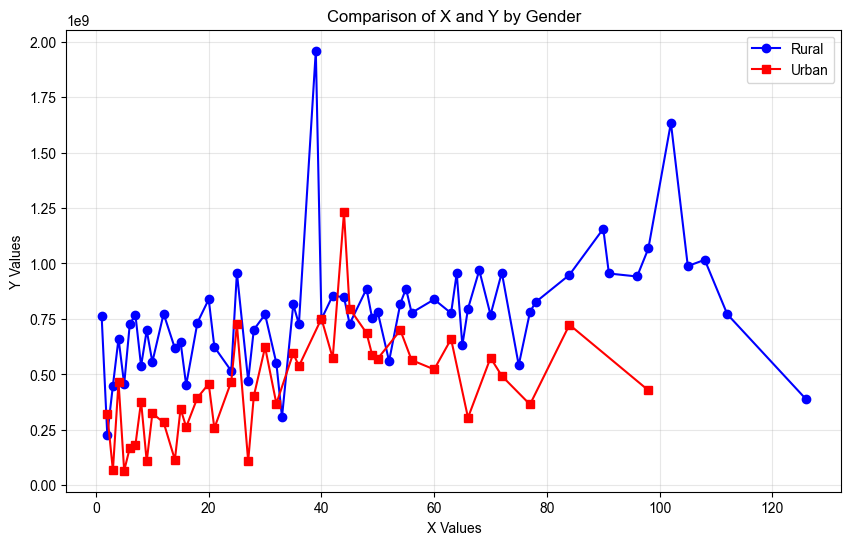

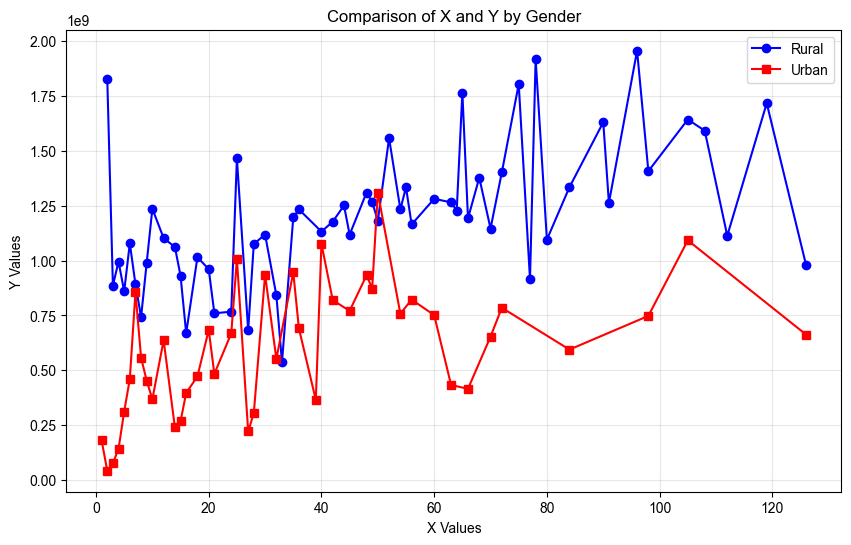

In [142]:
for year in range(1393, 1403):
    Members_Total_Income = csvfind("Members_Total_Income", year)
    members = csvfind("members_properties", year)
    income_info = csvfind("employment_income", year)
    members["Year"] =year
    members =  hbsir.add_attribute(table=members, name='Province',year_col="Year" ,id_col="ID")
    members = hbsir.add_attribute(table=members, name="Urban_Rural",year_col="Year" ,id_col="ID")
    members = hbsir.add_attribute(table=members, name="County",year_col="Year" ,id_col="ID")
    members =  pd.merge(members, Members_Total_Income, on=['ID','Member_Number'])
    members =  pd.merge(members, income_info, on=['ID','Member_Number'])

    # womenmembers = members[members['Sex'] == 'Female']
    # menmembers =  members[members['Sex'] == 'Male']
    members =  members[members["Age"] >=10 ]
    employed = members[members["Activity_Status"] =="Employed"]
    findjobs = members[(members["Activity_Status"] =="Employed")|(members["Activity_Status"] =="Unemployed")]
    haveIncome = members[(members["Activity_Status"] =="Employed")|(members["Activity_Status"] =="Income_without_Work")]
    numberOf_findjobs_woman = len(findjobs[findjobs['Sex'] == 'Female'])
    numberOf_all_woman = len(members[members['Sex'] == 'Female'])
    numberOf_haveIncome_woman = len(haveIncome[haveIncome['Sex'] == 'Female'])
    # Female Labor Force Participation Rate - FLFPR
    FLFPR =  (numberOf_findjobs_woman / numberOf_all_woman)*100
    # Income_Recipiency_Rate
    Income_Recipiency_Rate_female =  (numberOf_haveIncome_woman / numberOf_all_woman)*100
    # mean_income_women
    mean_income_women = employed[employed['Sex'] == 'Female']['Income'].mean()

    numberOf_findjobs_man = len(findjobs[findjobs['Sex'] == 'Male'])
    numberOf_all_man = len(members[members['Sex'] == 'Male'])
    numberOf_haveIncome_man = len(haveIncome[haveIncome['Sex'] == 'Male'])
    # Male Labor Force Participation Rate - MLFPR
    MLFPR =  (numberOf_findjobs_man / numberOf_all_man)*100
    # Income_Recipiency_Rate
    Income_Recipiency_Rate_male =  (numberOf_haveIncome_man / numberOf_all_man)*100
    # mean_income_women
    mean_income_men = employed[employed['Sex'] == 'Male']['Income'].mean()
    # pay_gap
    pay_gap = ((mean_income_men - mean_income_women) / mean_income_men) * 100



    diff_employed = employed.dropna(subset=["Working_Hours_per_Day","Working_Day_per_Week"])
    diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]
    diff_employed_men = diff_employed[diff_employed['Sex'] == 'Male']
    diff_employed_women = diff_employed[diff_employed['Sex'] == 'Female']
    diff_employed_men = diff_employed_men.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
    diff_employed_women = diff_employed_women.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
    print(f"****************************************** {year}****************************************** ")
    plt.figure(figsize=(10, 6))

    plt.plot(diff_employed_men["Working_Hours_per_Week"], diff_employed_men['Income'],
             label='Rural', color='blue', marker='o', linestyle='-')

    plt.plot(diff_employed_women['Working_Hours_per_Week'], diff_employed_women['Income'],
             label='Urban', color='red', marker='s', linestyle='-')

    plt.title('Comparison of X and Y by Gender')
    plt.xlabel('X Values')
    plt.ylabel('Y Values')

    plt.legend()

    plt.grid(True, alpha=0.3)
    print(f"pay gap: {pay_gap:.2f} %")
    print("_____________Female____________")
    print(f"mean_income_of_women : {mean_income_women:.0f} Rial")
    print(f"Female Labor Force Participation Rate in {year} :{FLFPR:.2f}%")
    print(f"Female_Income_Recipiency_Rate :{Income_Recipiency_Rate_female:.2f}%")
    print("_____________Male____________")
    print(f"mean_income_of_men : {mean_income_men:.0f} Rial")
    print(f"Male Labor Force Participation Rate in {year} :{MLFPR:.2f}%")
    print(f"Male_Income_Recipiency_Rate :{Income_Recipiency_Rate_male:.2f}%")

In [ ]:
year =1400
Members_Total_Income = csvfind("Members_Total_Income", year)
members = csvfind("members_properties", year)
income_info = csvfind("employment_income", year)
members["Year"] = year
members = hbsir.add_attribute(table=members, name='Province', year_col="Year", id_col="ID")
members = hbsir.add_attribute(table=members, name="Urban_Rural", year_col="Year", id_col="ID")
members = hbsir.add_attribute(table=members, name="County", year_col="Year", id_col="ID")
members = pd.merge(members, Members_Total_Income, on=['ID', 'Member_Number'])
members = pd.merge(members, income_info, on=['ID', 'Member_Number'])

# womenmembers = members[members['Sex'] == 'Female']
# menmembers =  members[members['Sex'] == 'Male']
members = members[members["Age"] >= 10]
employed = members[members["Activity_Status"] == "Employed"]
findjobs = members[(members["Activity_Status"] == "Employed") | (members["Activity_Status"] == "Unemployed")]
haveIncome = members[(members["Activity_Status"] == "Employed") | (members["Activity_Status"] == "Income_without_Work")]
numberOf_findjobs_woman = len(findjobs[findjobs['Sex'] == 'Female'])
numberOf_all_woman = len(members[members['Sex'] == 'Female'])
numberOf_haveIncome_woman = len(haveIncome[haveIncome['Sex'] == 'Female'])
# Female Labor Force Participation Rate - FLFPR
FLFPR = (numberOf_findjobs_woman / numberOf_all_woman) * 100
# Income_Recipiency_Rate
Income_Recipiency_Rate_female = (numberOf_haveIncome_woman / numberOf_all_woman) * 100
# mean_income_women
mean_income_women = employed[employed['Sex'] == 'Female']['Income'].mean()

numberOf_findjobs_man = len(findjobs[findjobs['Sex'] == 'Male'])
numberOf_all_man = len(members[members['Sex'] == 'Male'])
numberOf_haveIncome_man = len(haveIncome[haveIncome['Sex'] == 'Male'])
# Male Labor Force Participation Rate - MLFPR
MLFPR = (numberOf_findjobs_man / numberOf_all_man) * 100
# Income_Recipiency_Rate
Income_Recipiency_Rate_male = (numberOf_haveIncome_man / numberOf_all_man) * 100
# mean_income_women
mean_income_men = employed[employed['Sex'] == 'Male']['Income'].mean()
# pay_gap
pay_gap = ((mean_income_men - mean_income_women) / mean_income_men) * 100



diff_employed = employed.dropna(subset=["Working_Hours_per_Day", "Working_Day_per_Week"])
diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"] * diff_employed["Working_Day_per_Week"]
diff_employed_men = diff_employed[diff_employed['Sex'] == 'Male']
diff_employed_women = diff_employed[diff_employed['Sex'] == 'Female']
diff_employed_men = diff_employed_men.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
diff_employed_women = diff_employed_women.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
print(f"****************************************** {year}****************************************** ")
plt.figure(figsize=(10, 6))

plt.plot(diff_employed_men["Working_Hours_per_Week"], diff_employed_men['Income'],
         label='Rural', color='blue', marker='o', linestyle='-')

plt.plot(diff_employed_women['Working_Hours_per_Week'], diff_employed_women['Income'],
         label='Urban', color='red', marker='s', linestyle='-')

plt.title('Comparison of X and Y by Gender')
plt.xlabel('X Values')
plt.ylabel('Y Values')

plt.legend()

plt.grid(True, alpha=0.3)
print(f"pay gap: {pay_gap:.2f} %")
print("_____________Female____________")
print(f"mean_income_of_women : {mean_income_women:.0f} Rial")
print(f"Female Labor Force Participation Rate in {year} :{FLFPR:.2f}%")
print(f"Female_Income_Recipiency_Rate :{Income_Recipiency_Rate_female:.2f}%")
print("_____________Male____________")
print(f"mean_income_of_men : {mean_income_men:.0f} Rial")
print(f"Male Labor Force Participation Rate in {year} :{MLFPR:.2f}%")
print(f"Male_Income_Recipiency_Rate :{Income_Recipiency_Rate_male:.2f}%")